# Phase 9 — Aggregate Analysis & Report Figures

Pulls every JSON result written by earlier phases and produces one place
where the whole story is visible: a summary table, the baseline learning
curves, the SSL/SL/random comparison, each ablation overlay, and the
transfer-learning grouped bars. All figures go to `figures/` at 300 DPI
so they can be dropped straight into the writeup.

Missing results are skipped silently — so you can run this after any phase
and see what's currently available.


In [1]:
# --- Cell 1: Imports + helpers ---
import json, os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)
RES = Path('results')

def load(path):
    p = RES / path if not str(path).startswith('results/') else Path(path)
    if not p.exists(): return None
    try:    return json.loads(p.read_text())
    except Exception as e:
        print(f'  WARN could not parse {p}: {e}'); return None

def pct(x):
    return f'{x*100:.2f}%' if isinstance(x, (int, float)) else '   n/a '


In [2]:
# --- Cell 2: Summary table (all experiments) ---
rows = []

# Phase 1 — SimCLR baseline probe
p1 = load('simclr_baseline_linear_probe.json')
if p1:
    rows.append(('SimCLR (Phase 1, 200ep, probe)',
                 p1.get('final_test_acc'), p1.get('best_test_acc')))

# Phase 1b — SimCLR extended (600 ep)
p1b = load('simclr_extended_600ep_linear_probe.json')
if p1b:
    rows.append(('SimCLR extended (Phase 1b, 600ep, probe)',
                 p1b.get('final_test_acc'), p1b.get('best_test_acc')))

# Phase 2 — Supervised
p2 = load('supervised_baseline_log.json')
if p2 and isinstance(p2.get('test_acc'), list):
    rows.append(('Supervised (Phase 2)',
                 p2['test_acc'][-1], max(p2['test_acc'])))

# Phase 3 — Random init probe
p3 = load('random_baseline_linear_probe.json')
if p3:
    rows.append(('Random-init (Phase 3, probe)',
                 p3.get('final_test_acc'), p3.get('best_test_acc')))

# Phase 4 — temperature
p4 = load('ablation_temperature.json')
if p4:
    for tau_str, d in p4.get('runs', {}).items():
        r = d.get('probe', {})
        rows.append((f'SimCLR tau={tau_str} (Phase 4)',
                     r.get('final_test_acc'), r.get('best_test_acc')))

# Phase 5 — batch size
p5 = load('ablation_batchsize.json')
if p5:
    for bs_str, d in p5.get('runs', {}).items():
        r = d.get('probe', {})
        rows.append((f'SimCLR bs={bs_str} (Phase 5)',
                     r.get('final_test_acc'), r.get('best_test_acc')))

# Phase 6 — augmentation
p6 = load('ablation_augmentation.json')
if p6:
    for name, d in p6.get('runs', {}).items():
        r = d.get('probe', {})
        rows.append((f'SimCLR aug={name} (Phase 6)',
                     r.get('final_test_acc'), r.get('best_test_acc')))

# Phase 7 — projector
p7 = load('ablation_projector.json')
if p7:
    for key, r in p7.get('runs', {}).items():
        rows.append((f'{r.get("tag", key)} (Phase 7)',
                     r.get('final_test_acc'), r.get('best_test_acc')))

# Phase 8 — transfer
p8 = load('transfer_learning_results.json')
if p8:
    for ds_name, bb_dict in p8.items():
        for bb_name, r in bb_dict.items():
            rows.append((f'Transfer: {ds_name} / {bb_name} (Phase 8)',
                         r.get('final_test_acc'), r.get('best_test_acc')))

print('Master summary — CIFAR-10 (or listed dataset) test accuracy')
print('=' * 72)
print(f"{'experiment':<48}  {'final':>10}  {'best':>10}")
print('-' * 72)
for name, fi, be in rows:
    print(f'{name:<48}  {pct(fi):>10}  {pct(be):>10}')
print(f'\n{len(rows)} experiments found.')


Master summary — CIFAR-10 (or listed dataset) test accuracy
experiment                                             final        best
------------------------------------------------------------------------
SimCLR (Phase 1, 200ep, probe)                        86.34%      86.70%
SimCLR extended (Phase 1b, 600ep, probe)              88.56%      88.88%
Supervised (Phase 2)                                  91.47%      92.54%
Random-init (Phase 3, probe)                          41.39%      41.76%
SimCLR tau=0.1 (Phase 4)                              81.45%      81.55%
SimCLR tau=1.0 (Phase 4)                              83.13%      83.13%
SimCLR tau=5.0 (Phase 4)                              76.16%      76.40%
SimCLR bs=128 (Phase 5)                               80.93%      80.93%
SimCLR bs=64 (Phase 5)                                80.55%      80.72%
SimCLR aug=no_color (Phase 6)                         73.27%      73.27%
SimCLR aug=no_gray (Phase 6)                          70.48%    

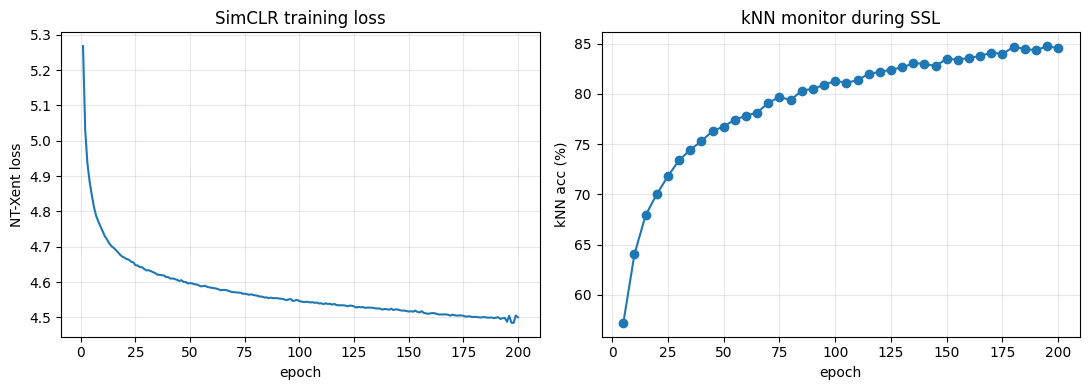

Saved fig1_simclr_baseline.png


In [3]:
# --- Cell 3: Fig 1 — SimCLR baseline (loss + kNN) ---
p1_log = load('simclr_baseline_log.json')
if p1_log:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(p1_log['epoch'], p1_log['loss'])
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('NT-Xent loss')
    axes[0].set_title('SimCLR training loss'); axes[0].grid(alpha=0.3)
    if p1_log.get('knn_epoch'):
        axes[1].plot(p1_log['knn_epoch'], [a*100 for a in p1_log['knn_acc']], marker='o')
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('kNN acc (%)')
    axes[1].set_title('kNN monitor during SSL'); axes[1].grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'fig1_simclr_baseline.png', dpi=300)
    plt.show(); print('Saved fig1_simclr_baseline.png')
else:
    print('skip fig1 (simclr_baseline_log.json missing)')


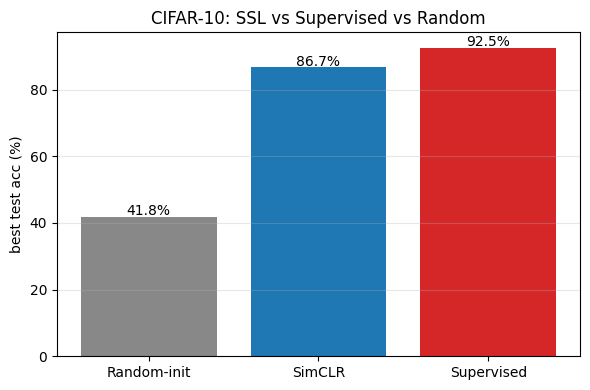

Saved fig2_cifar10_comparison.png


In [4]:
# --- Cell 4: Fig 2 — SSL vs SL vs Random on CIFAR-10 ---
ssl_best = (load('simclr_baseline_linear_probe.json') or {}).get('best_test_acc')
sl_log   = (load('supervised_baseline_log.json') or {}).get('test_acc')
sl_best  = max(sl_log) if isinstance(sl_log, list) else None
rand_best= (load('random_baseline_linear_probe.json') or {}).get('best_test_acc')

vals = [('Random-init', rand_best), ('SimCLR', ssl_best), ('Supervised', sl_best)]
vals = [(n, v) for n, v in vals if v is not None]
if vals:
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    names = [n for n, _ in vals]; heights = [v*100 for _, v in vals]
    bars = ax.bar(names, heights, color=['#888', '#1f77b4', '#d62728'][:len(vals)])
    ax.set_ylabel('best test acc (%)')
    ax.set_title('CIFAR-10: SSL vs Supervised vs Random')
    ax.grid(axis='y', alpha=0.3)
    for b, v in zip(bars, heights):
        ax.text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.1f}%', ha='center')
    fig.tight_layout(); fig.savefig(FIG_DIR / 'fig2_cifar10_comparison.png', dpi=300)
    plt.show(); print('Saved fig2_cifar10_comparison.png')
else:
    print('skip fig2 (not enough results yet)')


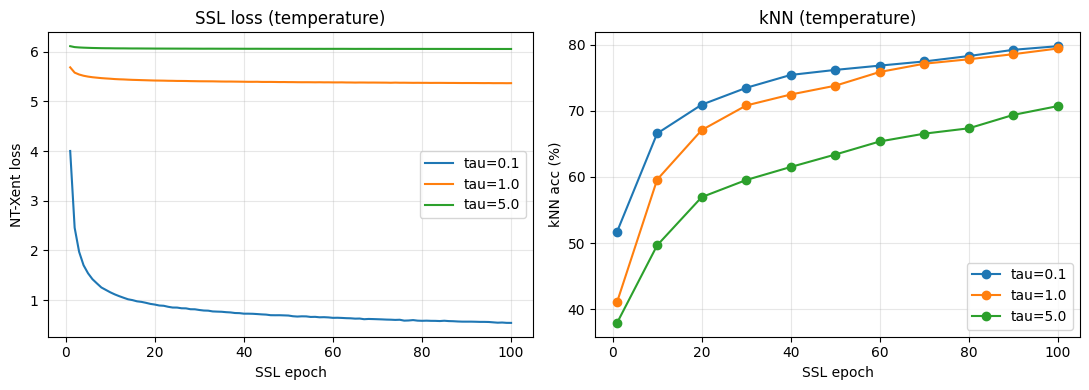

Saved fig3_ablation_temperature.png


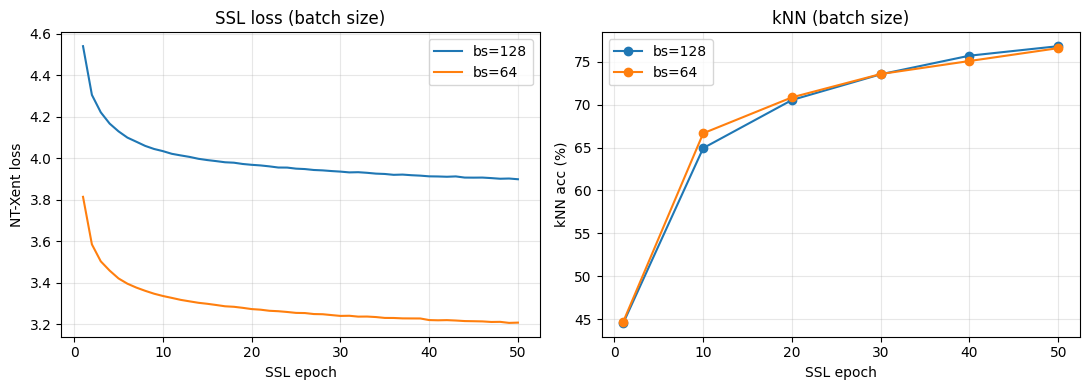

Saved fig4_ablation_batchsize.png


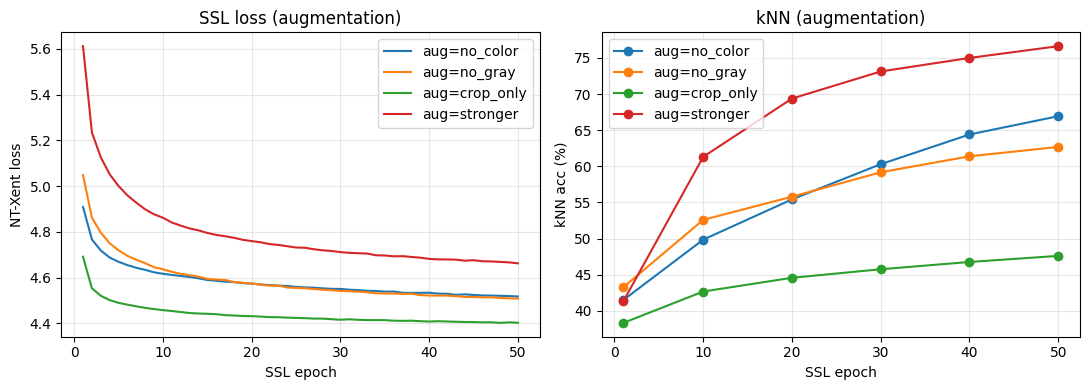

Saved fig5_ablation_augmentation.png


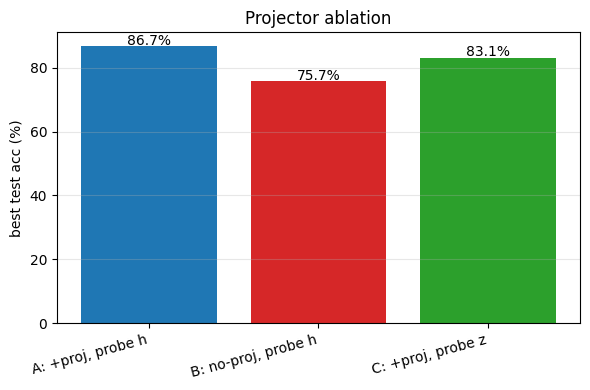

Saved fig6_ablation_projector.png


In [5]:
# --- Cell 5: Figs 3-6 — ablation overlays (if present) ---
def _plot_ablation_overlay(data, key_label, fig_name, title_extra=''):
    if not data or 'runs' not in data: return False
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for k, d in data['runs'].items():
        log = d.get('ssl_log', {})
        if log.get('epoch'):
            axes[0].plot(log['epoch'], log['loss'], label=f'{key_label}={k}')
        if log.get('knn_epoch'):
            axes[1].plot(log['knn_epoch'], [a*100 for a in log['knn_acc']],
                         marker='o', label=f'{key_label}={k}')
    axes[0].set_xlabel('SSL epoch'); axes[0].set_ylabel('NT-Xent loss')
    axes[0].set_title(f'SSL loss {title_extra}'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].set_xlabel('SSL epoch'); axes[1].set_ylabel('kNN acc (%)')
    axes[1].set_title(f'kNN {title_extra}'); axes[1].legend(); axes[1].grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(FIG_DIR / fig_name, dpi=300)
    plt.show(); print('Saved', fig_name); return True

# Fig 3 temperature
if not _plot_ablation_overlay(load('ablation_temperature.json'), 'tau',
                              'fig3_ablation_temperature.png', '(temperature)'):
    print('skip fig3')

# Fig 4 batch size
if not _plot_ablation_overlay(load('ablation_batchsize.json'), 'bs',
                              'fig4_ablation_batchsize.png', '(batch size)'):
    print('skip fig4')

# Fig 5 augmentation
if not _plot_ablation_overlay(load('ablation_augmentation.json'), 'aug',
                              'fig5_ablation_augmentation.png', '(augmentation)'):
    print('skip fig5')

# Fig 6 projector — different shape (3 bars)
p7 = load('ablation_projector.json')
if p7 and p7.get('runs'):
    runs = p7['runs']
    keys = ['A_proj_h', 'B_noproj_h', 'C_proj_z']
    tags = [runs[k]['tag'] for k in keys if k in runs]
    vals = [runs[k]['best_test_acc']*100 for k in keys if k in runs]
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.bar(range(len(vals)), vals, color=['#1f77b4', '#d62728', '#2ca02c'][:len(vals)])
    ax.set_xticks(range(len(tags))); ax.set_xticklabels(tags, rotation=15, ha='right')
    ax.set_ylabel('best test acc (%)'); ax.set_title('Projector ablation')
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(vals):
        ax.text(i, v+0.5, f'{v:.1f}%', ha='center')
    fig.tight_layout(); fig.savefig(FIG_DIR / 'fig6_ablation_projector.png', dpi=300)
    plt.show(); print('Saved fig6_ablation_projector.png')
else:
    print('skip fig6')


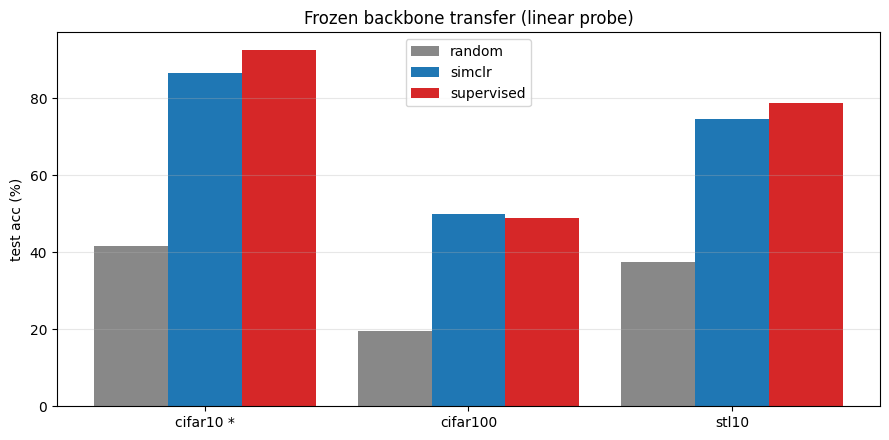

Saved fig7_transfer_learning.png


In [6]:
# --- Cell 6: Fig 7 — Transfer learning grouped bar chart ---
p8 = load('transfer_learning_results.json')
if p8:
    datasets = list(p8.keys())
    # Prepend CIFAR-10 row if we have those numbers handy
    c10 = {
        'random':     (load('random_baseline_linear_probe.json') or {}).get('best_test_acc'),
        'simclr':     (load('simclr_baseline_linear_probe.json') or {}).get('best_test_acc'),
        'supervised': None,
    }
    sl = (load('supervised_baseline_log.json') or {}).get('test_acc')
    if isinstance(sl, list): c10['supervised'] = max(sl)

    all_datasets = ['cifar10 *'] + datasets
    bb_order = ['random', 'simclr', 'supervised']
    heights = {b: [] for b in bb_order}
    for ds in all_datasets:
        for b in bb_order:
            if ds == 'cifar10 *':
                v = c10.get(b)
            else:
                v = p8.get(ds, {}).get(b, {}).get('best_test_acc')
            heights[b].append(v*100 if v is not None else 0)

    x = np.arange(len(all_datasets)); w = 0.28
    fig, ax = plt.subplots(figsize=(9, 4.5))
    colors = {'random': '#888', 'simclr': '#1f77b4', 'supervised': '#d62728'}
    for i, b in enumerate(bb_order):
        ax.bar(x + (i-1)*w, heights[b], w, label=b, color=colors[b])
    ax.set_xticks(x); ax.set_xticklabels(all_datasets)
    ax.set_ylabel('test acc (%)'); ax.set_title('Frozen backbone transfer (linear probe)')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    fig.tight_layout(); fig.savefig(FIG_DIR / 'fig7_transfer_learning.png', dpi=300)
    plt.show(); print('Saved fig7_transfer_learning.png')
else:
    print('skip fig7 (transfer_learning_results.json missing)')


In [7]:
# --- Cell 7: Dump summary rows to CSV ---
import csv
csv_path = RES / 'summary_all_experiments.csv'
with csv_path.open('w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['experiment', 'final_test_acc', 'best_test_acc'])
    for name, fi, be in rows:
        w.writerow([name,
                    f'{fi*100:.2f}' if isinstance(fi, (int,float)) else '',
                    f'{be*100:.2f}' if isinstance(be, (int,float)) else ''])
print('Saved', csv_path)


Saved results\summary_all_experiments.csv
